In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import sys; sys.path.insert(0, '../..')
from feature_engineering import add_trend_features

## 1-day Horizon

In [2]:
df = pd.read_csv('../../data/dataset-no-recessions.csv', parse_dates=['Date']).set_index('Date').sort_index()
df = add_trend_features(df)
df.head(3)

,BAA10Y,DFF,DGS10,DGS2,CPIAUCSL,CPIAUCSL_days_since,PPIACO,PPIACO_days_since,PCEPI,PCEPI_days_since,...,BAA10Y_roll5_std,BAA10Y_roll21_std,BAA10Y_mom5,BAA10Y_mom21,yield_curve_slope,VIX_roll5_mean,VIX_roll21_mean,SP500_mom21,DFF_mom21,credit_tier_spread
Date,,,,,,,,,,,,,,,,,,,,,
1990-01-01,NaN,7.97,NaN,NaN,127.5,0.0,114.9,0.0,58.553,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-02,1.91,8.54,7.94,7.87,127.5,1.0,114.9,1.0,58.553,1.0,...,NaN,NaN,NaN,NaN,0.07,NaN,NaN,NaN,NaN,0.98
1990-01-03,1.87,8.37,7.99,7.94,127.5,2.0,114.9,2.0,58.553,2.0,...,NaN,NaN,NaN,NaN,0.05,NaN,NaN,NaN,NaN,0.96


In [ ]:
# Forecast horizon (days ahead). Change this to forecast further out.
H = 1

# Supervised setup: features at time t predict BAA10Y at time t+H.
# Shifting by -H aligns each row's target with the future value.
y_future = df['BAA10Y'].shift(-H)
y_now    = df['BAA10Y']
X_full   = df.drop(columns=['BAA10Y'])
X_full['BAA10Y_current'] = df['BAA10Y']  # current spread as explicit feature

# Drop rows where target, current spread, or any feature is NaN.
# The trend features (rolling windows) introduce NaN at the series start.
mask = y_future.notna() & y_now.notna() & X_full.notna().all(axis=1)
X = X_full.loc[mask]
y = y_future.loc[mask]
y_t = y_now.loc[mask]  # current spread, kept for the naive last-value baseline

print(f"Horizon H = {H} day(s)")
print(f"Samples: {len(y)}  ({y.index.min().date()} → {y.index.max().date()})")

Horizon H = 7 day(s)
Samples: 11618  (1990-03-05 → 2025-12-25)


In [4]:
TRAIN_WINDOW_YEARS = 30
start_eval_year = 2000

folds = []
for year in range(start_eval_year, y.index.year.max() + 1):
    # Rolling 30-year window: use at most the last 30 years of training data.
    # Falls back to all available data when fewer than 30 years exist.
    train_start = max(X.index.min(), pd.Timestamp(f"{year - TRAIN_WINDOW_YEARS}-10-01"))
    train_end  = pd.Timestamp(f"{year}-09-30")
    test_start = pd.Timestamp(f"{year}-10-01")
    test_end   = pd.Timestamp(f"{year}-12-31")

    train_mask = (X.index >= train_start) & (X.index <= train_end)
    test_mask  = (X.index >= test_start) & (X.index <= test_end)

    if train_mask.sum() > 0 and test_mask.sum() > 0:
        folds.append({
            'year':     year,
            'X_train':  X.loc[train_mask],
            'y_train':  y.loc[train_mask],
            'X_test':   X.loc[test_mask],
            'y_test':   y.loc[test_mask],
            'y_t_test': y_t.loc[test_mask],
        })

print(f"Folds: {len(folds)}  ({folds[0]['year']} → {folds[-1]['year']})")
for f in folds[:3] + [folds[-1]]:
    print(f"  {f['year']}: train {f['X_train'].index.min().date()} → "
          f"{f['X_train'].index.max().date()} ({len(f['X_train'])} rows) | "
          f"test {f['X_test'].index.min().date()} → "
          f"{f['X_test'].index.max().date()} ({len(f['X_test'])} rows)")

Folds: 24  (2000 → 2025)
  2000: train 1990-03-05 → 2000-09-30 (3497 rows) | test 2000-10-01 → 2000-12-31 (92 rows)
  2002: train 1990-03-05 → 2002-09-30 (3952 rows) | test 2002-10-01 → 2002-12-31 (92 rows)
  2003: train 1990-03-05 → 2003-09-30 (4317 rows) | test 2003-10-01 → 2003-12-31 (92 rows)
  2025: train 1995-10-01 → 2025-09-30 (9862 rows) | test 2025-10-01 → 2025-12-25 (86 rows)


In [5]:
# Run OOB sweep on the first fold's training set to select n_estimators.
# Subsequent folds reuse this choice, keeping the sweep cost fixed.
X_oob = folds[0]['X_train']
y_oob = folds[0]['y_train']

n_grid = list(range(100, 1501, 100))

rf = RandomForestRegressor(
    n_estimators=n_grid[0],
    oob_score=True,
    bootstrap=True,
    warm_start=True,
    n_jobs=-1,
    random_state=42,
)

oob_rmse  = []
mean_depth = []
max_depth  = []
min_depth  = []

for n in n_grid:
    rf.set_params(n_estimators=n)
    rf.fit(X_oob, y_oob)
    rmse = np.sqrt(mean_squared_error(y_oob, rf.oob_prediction_))
    depths = np.array([t.get_depth() for t in rf.estimators_])
    oob_rmse.append(rmse)
    mean_depth.append(depths.mean())
    max_depth.append(depths.max())
    min_depth.append(depths.min())
    print(f"n_estimators={n:4d}  OOB RMSE={rmse:.4f}  "
          f"depth mean={depths.mean():5.1f}  min={depths.min():3d}  max={depths.max():3d}")

n_estimators= 100  OOB RMSE=0.0262  depth mean= 24.1  min= 21  max= 30
n_estimators= 200  OOB RMSE=0.0257  depth mean= 24.3  min= 21  max= 31
n_estimators= 300  OOB RMSE=0.0257  depth mean= 24.3  min= 20  max= 32
n_estimators= 400  OOB RMSE=0.0257  depth mean= 24.4  min= 20  max= 32
n_estimators= 500  OOB RMSE=0.0257  depth mean= 24.4  min= 20  max= 32
n_estimators= 600  OOB RMSE=0.0257  depth mean= 24.4  min= 20  max= 32
n_estimators= 700  OOB RMSE=0.0257  depth mean= 24.4  min= 20  max= 32
n_estimators= 800  OOB RMSE=0.0256  depth mean= 24.4  min= 20  max= 32
n_estimators= 900  OOB RMSE=0.0256  depth mean= 24.4  min= 20  max= 32
n_estimators=1000  OOB RMSE=0.0256  depth mean= 24.4  min= 20  max= 32
n_estimators=1100  OOB RMSE=0.0256  depth mean= 24.4  min= 20  max= 32
n_estimators=1200  OOB RMSE=0.0256  depth mean= 24.3  min= 20  max= 32
n_estimators=1300  OOB RMSE=0.0256  depth mean= 24.3  min= 20  max= 32
n_estimators=1400  OOB RMSE=0.0256  depth mean= 24.3  min= 20  max= 32
n_esti

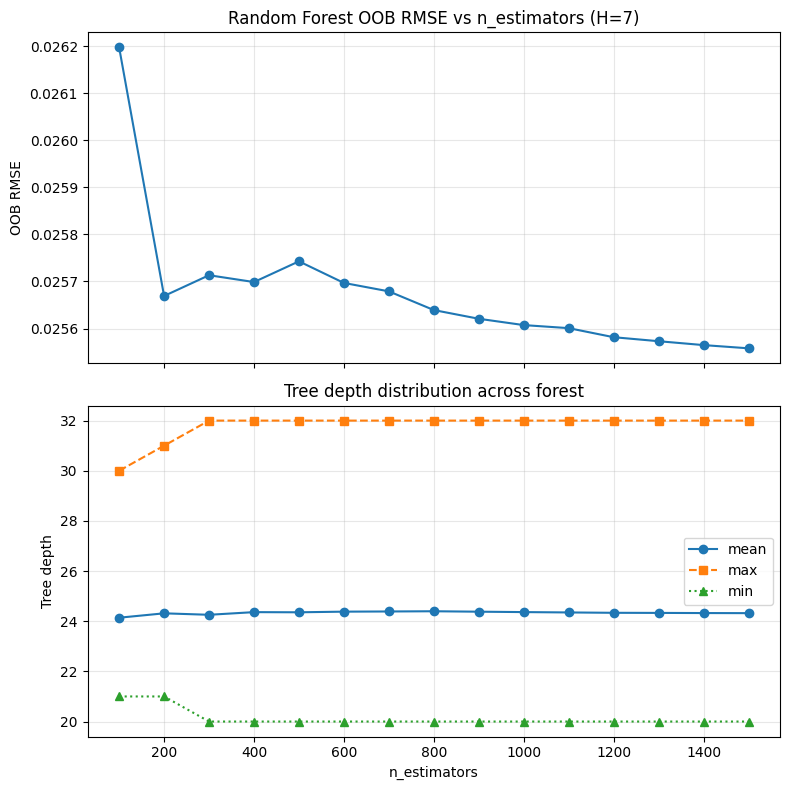

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axes[0].plot(n_grid, oob_rmse, marker='o')
axes[0].set_ylabel('OOB RMSE')
axes[0].set_title(f'Random Forest OOB RMSE vs n_estimators (H={H})')
axes[0].grid(True, alpha=0.3)

axes[1].plot(n_grid, mean_depth, marker='o', label='mean')
axes[1].plot(n_grid, max_depth,  marker='s', label='max', linestyle='--')
axes[1].plot(n_grid, min_depth,  marker='^', label='min', linestyle=':')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Tree depth')
axes[1].set_title('Tree depth distribution across forest')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
best_n = n_grid[np.argmin(oob_rmse)]
print(f"Best n_estimators: {best_n}\n")

feature_names = folds[0]['X_train'].columns.tolist()
fold_results  = []
all_y_test    = []
all_y_pred    = []
all_y_curr    = []
all_importances = []

for fold in folds:
    rf_fold = RandomForestRegressor(
        n_estimators=best_n,
        bootstrap=True,
        n_jobs=-1,
        random_state=42,
    )
    rf_fold.fit(fold['X_train'], fold['y_train'])
    all_importances.append(rf_fold.feature_importances_)

    y_pred_fold = pd.Series(rf_fold.predict(fold['X_test']), index=fold['y_test'].index)
    y_true = fold['y_test']
    y_curr = fold['y_t_test']

    mae       = mean_absolute_error(y_true, y_pred_fold)
    rmse      = np.sqrt(mean_squared_error(y_true, y_pred_fold))
    ss_res    = np.sum((y_true - y_pred_fold) ** 2)
    ss_tot    = np.sum((y_true - y_true.mean()) ** 2)
    r2        = 1 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
    naive_mae = mean_absolute_error(y_true, y_curr)

    act_dir  = np.sign(y_true.values - y_curr.values)
    pred_dir = np.sign(y_pred_fold.values - y_curr.values)
    non_flat = act_dir != 0
    dir_acc  = (act_dir[non_flat] == pred_dir[non_flat]).mean() if non_flat.sum() > 0 else np.nan

    fold_results.append({
        'year': fold['year'], 'n_test': len(y_true),
        'MAE_RF': mae, 'MAE_naive': naive_mae,
        'RMSE': rmse, 'R2': r2, 'dir_acc': dir_acc,
    })
    all_y_test.append(y_true)
    all_y_pred.append(y_pred_fold)
    all_y_curr.append(y_curr)
    print(f"{fold['year']}: MAE={mae:.4f} (naive={naive_mae:.4f})  "
          f"RMSE={rmse:.4f}  R²={r2:6.3f}  DirAcc={dir_acc:.2%}")

y_test_all = pd.concat(all_y_test)
y_pred_all = pd.concat(all_y_pred)
y_curr_all = pd.concat(all_y_curr)
results_df = pd.DataFrame(fold_results).set_index('year')

print(f"\n{'':8} {'MAE RF':>8} {'Naive':>8} {'RMSE':>8} {'R²':>7} {'DirAcc':>8}")
print("-" * 52)
print(f"{'Mean':8} {results_df['MAE_RF'].mean():>8.4f} {results_df['MAE_naive'].mean():>8.4f} "
      f"{results_df['RMSE'].mean():>8.4f} {results_df['R2'].mean():>7.3f} "
      f"{results_df['dir_acc'].mean():>8.2%}")

Best n_estimators: 1500

2000: MAE=0.1420 (naive=0.0618)  RMSE=0.1751  R²=-0.625  DirAcc=39.56%
2002: MAE=0.1449 (naive=0.0743)  RMSE=0.1575  R²= 0.204  DirAcc=56.47%
2003: MAE=0.1208 (naive=0.0353)  RMSE=0.1270  R²=-5.738  DirAcc=37.04%
2004: MAE=0.0539 (naive=0.0243)  RMSE=0.0662  R²= 0.428  DirAcc=32.89%
2005: MAE=0.0177 (naive=0.0222)  RMSE=0.0229  R²= 0.229  DirAcc=75.00%
2006: MAE=0.0248 (naive=0.0241)  RMSE=0.0285  R²= 0.455  DirAcc=64.29%
2007: MAE=0.1175 (naive=0.1029)  RMSE=0.1638  R²= 0.707  DirAcc=36.26%
2009: MAE=0.0748 (naive=0.0593)  RMSE=0.0858  R²= 0.615  DirAcc=55.00%
2010: MAE=0.0736 (naive=0.0777)  RMSE=0.0952  R²= 0.807  DirAcc=59.34%
2011: MAE=0.0632 (naive=0.0548)  RMSE=0.0865  R²= 0.135  DirAcc=57.65%
2012: MAE=0.0867 (naive=0.0529)  RMSE=0.1059  R²=-0.990  DirAcc=50.00%
2013: MAE=0.0935 (naive=0.0411)  RMSE=0.1142  R²= 0.202  DirAcc=22.09%
2014: MAE=0.0481 (naive=0.0458)  RMSE=0.0619  R²= 0.042  DirAcc=58.89%
2015: MAE=0.0364 (naive=0.0351)  RMSE=0.0439  R²=-0.

In [8]:
actual_direction    = np.sign(y_test_all.values - y_curr_all.values)
predicted_direction = np.sign(y_pred_all.values - y_curr_all.values)
naive_direction     = np.zeros(len(y_test_all))

non_flat = actual_direction != 0
dir_acc_rf    = (actual_direction[non_flat] == predicted_direction[non_flat]).mean()
dir_acc_naive = (actual_direction[non_flat] == naive_direction[non_flat]).mean()

up_mask   = actual_direction[non_flat] == 1
down_mask = actual_direction[non_flat] == -1

print(f"Overall directional accuracy across all folds (excl. flat moves, n={non_flat.sum()}):")
print(f"  RF model : {dir_acc_rf:.2%}")
print(f"  Naive    : {dir_acc_naive:.2%}")
print(f"\nBreakdown by actual direction:")
print(f"  Actual UP   ({up_mask.sum():4d} days): RF correct {(predicted_direction[non_flat][up_mask] == 1).mean():.2%}")
print(f"  Actual DOWN ({down_mask.sum():4d} days): RF correct {(predicted_direction[non_flat][down_mask] == -1).mean():.2%}")

Overall directional accuracy across all folds (excl. flat moves, n=2041):
  RF model : 53.85%
  Naive    : 0.00%

Breakdown by actual direction:
  Actual UP   ( 853 days): RF correct 60.38%
  Actual DOWN (1188 days): RF correct 49.16%


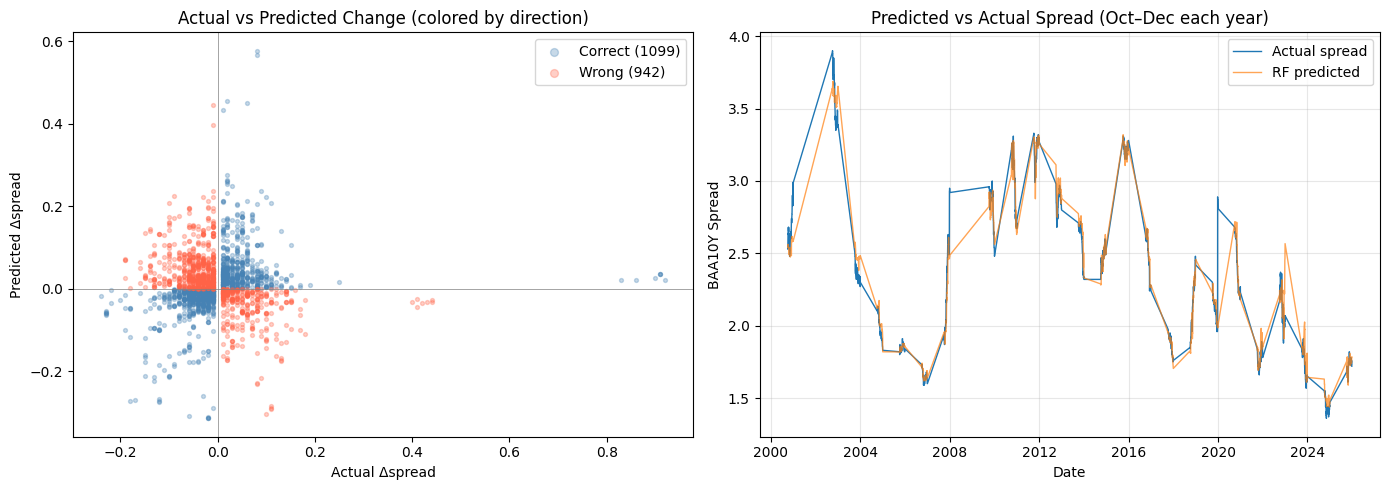

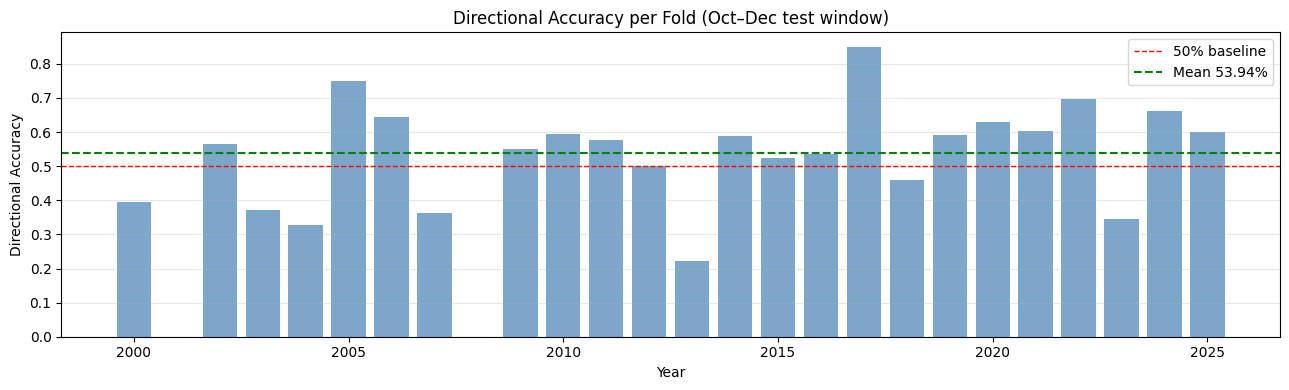

In [9]:
delta_actual = y_test_all.values - y_curr_all.values
delta_pred   = y_pred_all.values - y_curr_all.values

correct = actual_direction == predicted_direction
wrong   = ~correct & (actual_direction != 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(delta_actual[correct], delta_pred[correct], alpha=0.3, s=8,
           color='steelblue', label=f'Correct ({correct.sum()})')
ax.scatter(delta_actual[wrong],   delta_pred[wrong],   alpha=0.3, s=8,
           color='tomato',    label=f'Wrong ({wrong.sum()})')
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
ax.set_xlabel('Actual \u0394spread')
ax.set_ylabel('Predicted \u0394spread')
ax.set_title('Actual vs Predicted Change (colored by direction)')
ax.legend(markerscale=2)

ax = axes[1]
ax.plot(y_test_all.index, y_test_all.values, label='Actual spread', lw=1)
ax.plot(y_test_all.index, y_pred_all.values, label='RF predicted',  lw=1, alpha=0.7)
ax.set_xlabel('Date')
ax.set_ylabel('BAA10Y Spread')
ax.set_title('Predicted vs Actual Spread (Oct\u2013Dec each year)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(results_df.index, results_df['dir_acc'], color='steelblue', alpha=0.7)
ax.axhline(0.5, color='red',   lw=1,   linestyle='--', label='50% baseline')
ax.axhline(results_df['dir_acc'].mean(), color='green', lw=1.5, linestyle='--',
           label=f"Mean {results_df['dir_acc'].mean():.2%}")
ax.set_xlabel('Year')
ax.set_ylabel('Directional Accuracy')
ax.set_title('Directional Accuracy per Fold (Oct\u2013Dec test window)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

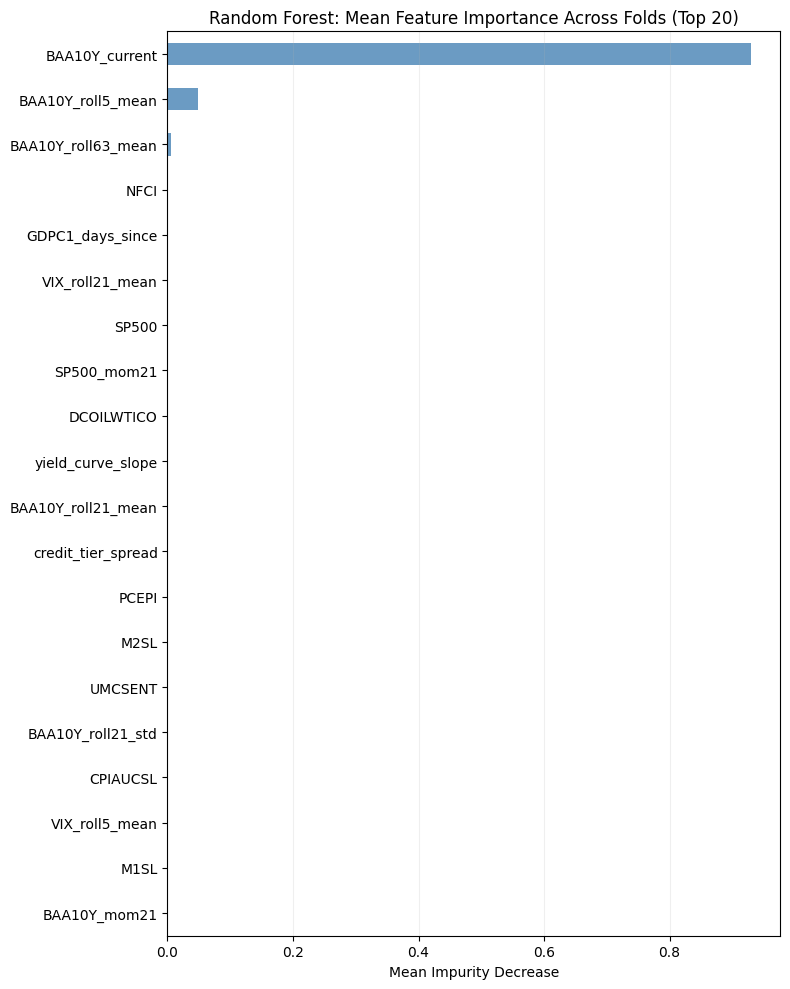

In [10]:
mean_imp = pd.Series(
    np.mean(all_importances, axis=0),
    index=feature_names
).sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
mean_imp.tail(20).plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Random Forest: Mean Feature Importance Across Folds (Top 20)')
ax.set_xlabel('Mean Impurity Decrease')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.show()

## 7-day Horizon

In [ ]:
df = pd.read_csv('../../data/dataset-no-recessions.csv', parse_dates=['Date']).set_index('Date').sort_index()
df = add_trend_features(df)
df.head(3)

In [ ]:
# Forecast horizon (days ahead). Change this to forecast further out.
H = 7

# Supervised setup: features at time t predict BAA10Y at time t+H.
# Shifting by -H aligns each row's target with the future value.
y_future = df['BAA10Y'].shift(-H)
y_now    = df['BAA10Y']
X_full   = df.drop(columns=['BAA10Y'])
X_full['BAA10Y_current'] = df['BAA10Y']  # current spread as explicit feature

# Drop rows where target, current spread, or any feature is NaN.
# The trend features (rolling windows) introduce NaN at the series start.
mask = y_future.notna() & y_now.notna() & X_full.notna().all(axis=1)
X = X_full.loc[mask]
y = y_future.loc[mask]
y_t = y_now.loc[mask]  # current spread, kept for the naive last-value baseline

print(f"Horizon H = {H} day(s)")
print(f"Samples: {len(y)}  ({y.index.min().date()} → {y.index.max().date()})")

In [ ]:
TRAIN_WINDOW_YEARS = 30
start_eval_year = 2000

folds = []
for year in range(start_eval_year, y.index.year.max() + 1):
    # Rolling 30-year window: use at most the last 30 years of training data.
    # Falls back to all available data when fewer than 30 years exist.
    train_start = max(X.index.min(), pd.Timestamp(f"{year - TRAIN_WINDOW_YEARS}-10-01"))
    train_end  = pd.Timestamp(f"{year}-09-30")
    test_start = pd.Timestamp(f"{year}-10-01")
    test_end   = pd.Timestamp(f"{year}-12-31")

    train_mask = (X.index >= train_start) & (X.index <= train_end)
    test_mask  = (X.index >= test_start) & (X.index <= test_end)

    if train_mask.sum() > 0 and test_mask.sum() > 0:
        folds.append({
            'year':     year,
            'X_train':  X.loc[train_mask],
            'y_train':  y.loc[train_mask],
            'X_test':   X.loc[test_mask],
            'y_test':   y.loc[test_mask],
            'y_t_test': y_t.loc[test_mask],
        })

print(f"Folds: {len(folds)}  ({folds[0]['year']} → {folds[-1]['year']})")
for f in folds[:3] + [folds[-1]]:
    print(f"  {f['year']}: train {f['X_train'].index.min().date()} → "
          f"{f['X_train'].index.max().date()} ({len(f['X_train'])} rows) | "
          f"test {f['X_test'].index.min().date()} → "
          f"{f['X_test'].index.max().date()} ({len(f['X_test'])} rows)")

In [ ]:
# Run OOB sweep on the first fold's training set to select n_estimators.
# Subsequent folds reuse this choice, keeping the sweep cost fixed.
X_oob = folds[0]['X_train']
y_oob = folds[0]['y_train']

n_grid = list(range(100, 1501, 100))

rf = RandomForestRegressor(
    n_estimators=n_grid[0],
    oob_score=True,
    bootstrap=True,
    warm_start=True,
    n_jobs=-1,
    random_state=42,
)

oob_rmse  = []
mean_depth = []
max_depth  = []
min_depth  = []

for n in n_grid:
    rf.set_params(n_estimators=n)
    rf.fit(X_oob, y_oob)
    rmse = np.sqrt(mean_squared_error(y_oob, rf.oob_prediction_))
    depths = np.array([t.get_depth() for t in rf.estimators_])
    oob_rmse.append(rmse)
    mean_depth.append(depths.mean())
    max_depth.append(depths.max())
    min_depth.append(depths.min())
    print(f"n_estimators={n:4d}  OOB RMSE={rmse:.4f}  "
          f"depth mean={depths.mean():5.1f}  min={depths.min():3d}  max={depths.max():3d}")

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axes[0].plot(n_grid, oob_rmse, marker='o')
axes[0].set_ylabel('OOB RMSE')
axes[0].set_title(f'Random Forest OOB RMSE vs n_estimators (H={H})')
axes[0].grid(True, alpha=0.3)

axes[1].plot(n_grid, mean_depth, marker='o', label='mean')
axes[1].plot(n_grid, max_depth,  marker='s', label='max', linestyle='--')
axes[1].plot(n_grid, min_depth,  marker='^', label='min', linestyle=':')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Tree depth')
axes[1].set_title('Tree depth distribution across forest')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
best_n = n_grid[np.argmin(oob_rmse)]
print(f"Best n_estimators: {best_n}\n")

feature_names = folds[0]['X_train'].columns.tolist()
fold_results  = []
all_y_test    = []
all_y_pred    = []
all_y_curr    = []
all_importances = []

for fold in folds:
    rf_fold = RandomForestRegressor(
        n_estimators=best_n,
        bootstrap=True,
        n_jobs=-1,
        random_state=42,
    )
    rf_fold.fit(fold['X_train'], fold['y_train'])
    all_importances.append(rf_fold.feature_importances_)

    y_pred_fold = pd.Series(rf_fold.predict(fold['X_test']), index=fold['y_test'].index)
    y_true = fold['y_test']
    y_curr = fold['y_t_test']

    mae       = mean_absolute_error(y_true, y_pred_fold)
    rmse      = np.sqrt(mean_squared_error(y_true, y_pred_fold))
    ss_res    = np.sum((y_true - y_pred_fold) ** 2)
    ss_tot    = np.sum((y_true - y_true.mean()) ** 2)
    r2        = 1 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
    naive_mae = mean_absolute_error(y_true, y_curr)

    act_dir  = np.sign(y_true.values - y_curr.values)
    pred_dir = np.sign(y_pred_fold.values - y_curr.values)
    non_flat = act_dir != 0
    dir_acc  = (act_dir[non_flat] == pred_dir[non_flat]).mean() if non_flat.sum() > 0 else np.nan

    fold_results.append({
        'year': fold['year'], 'n_test': len(y_true),
        'MAE_RF': mae, 'MAE_naive': naive_mae,
        'RMSE': rmse, 'R2': r2, 'dir_acc': dir_acc,
    })
    all_y_test.append(y_true)
    all_y_pred.append(y_pred_fold)
    all_y_curr.append(y_curr)
    print(f"{fold['year']}: MAE={mae:.4f} (naive={naive_mae:.4f})  "
          f"RMSE={rmse:.4f}  R²={r2:6.3f}  DirAcc={dir_acc:.2%}")

y_test_all = pd.concat(all_y_test)
y_pred_all = pd.concat(all_y_pred)
y_curr_all = pd.concat(all_y_curr)
results_df = pd.DataFrame(fold_results).set_index('year')

print(f"\n{'':8} {'MAE RF':>8} {'Naive':>8} {'RMSE':>8} {'R²':>7} {'DirAcc':>8}")
print("-" * 52)
print(f"{'Mean':8} {results_df['MAE_RF'].mean():>8.4f} {results_df['MAE_naive'].mean():>8.4f} "
      f"{results_df['RMSE'].mean():>8.4f} {results_df['R2'].mean():>7.3f} "
      f"{results_df['dir_acc'].mean():>8.2%}")

In [ ]:
actual_direction    = np.sign(y_test_all.values - y_curr_all.values)
predicted_direction = np.sign(y_pred_all.values - y_curr_all.values)
naive_direction     = np.zeros(len(y_test_all))

non_flat = actual_direction != 0
dir_acc_rf    = (actual_direction[non_flat] == predicted_direction[non_flat]).mean()
dir_acc_naive = (actual_direction[non_flat] == naive_direction[non_flat]).mean()

up_mask   = actual_direction[non_flat] == 1
down_mask = actual_direction[non_flat] == -1

print(f"Overall directional accuracy across all folds (excl. flat moves, n={non_flat.sum()}):")
print(f"  RF model : {dir_acc_rf:.2%}")
print(f"  Naive    : {dir_acc_naive:.2%}")
print(f"\nBreakdown by actual direction:")
print(f"  Actual UP   ({up_mask.sum():4d} days): RF correct {(predicted_direction[non_flat][up_mask] == 1).mean():.2%}")
print(f"  Actual DOWN ({down_mask.sum():4d} days): RF correct {(predicted_direction[non_flat][down_mask] == -1).mean():.2%}")

In [ ]:
delta_actual = y_test_all.values - y_curr_all.values
delta_pred   = y_pred_all.values - y_curr_all.values

correct = actual_direction == predicted_direction
wrong   = ~correct & (actual_direction != 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(delta_actual[correct], delta_pred[correct], alpha=0.3, s=8,
           color='steelblue', label=f'Correct ({correct.sum()})')
ax.scatter(delta_actual[wrong],   delta_pred[wrong],   alpha=0.3, s=8,
           color='tomato',    label=f'Wrong ({wrong.sum()})')
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
ax.set_xlabel('Actual \u0394spread')
ax.set_ylabel('Predicted \u0394spread')
ax.set_title('Actual vs Predicted Change (colored by direction)')
ax.legend(markerscale=2)

ax = axes[1]
ax.plot(y_test_all.index, y_test_all.values, label='Actual spread', lw=1)
ax.plot(y_test_all.index, y_pred_all.values, label='RF predicted',  lw=1, alpha=0.7)
ax.set_xlabel('Date')
ax.set_ylabel('BAA10Y Spread')
ax.set_title('Predicted vs Actual Spread (Oct\u2013Dec each year)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(results_df.index, results_df['dir_acc'], color='steelblue', alpha=0.7)
ax.axhline(0.5, color='red',   lw=1,   linestyle='--', label='50% baseline')
ax.axhline(results_df['dir_acc'].mean(), color='green', lw=1.5, linestyle='--',
           label=f"Mean {results_df['dir_acc'].mean():.2%}")
ax.set_xlabel('Year')
ax.set_ylabel('Directional Accuracy')
ax.set_title('Directional Accuracy per Fold (Oct\u2013Dec test window)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
mean_imp = pd.Series(
    np.mean(all_importances, axis=0),
    index=feature_names
).sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
mean_imp.tail(20).plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Random Forest: Mean Feature Importance Across Folds (Top 20)')
ax.set_xlabel('Mean Impurity Decrease')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.show()

## 28-day Horizon

In [ ]:
df = pd.read_csv('../../data/dataset-no-recessions.csv', parse_dates=['Date']).set_index('Date').sort_index()
df = add_trend_features(df)
df.head(3)

In [ ]:
# Forecast horizon (days ahead). Change this to forecast further out.
H = 28

# Supervised setup: features at time t predict BAA10Y at time t+H.
# Shifting by -H aligns each row's target with the future value.
y_future = df['BAA10Y'].shift(-H)
y_now    = df['BAA10Y']
X_full   = df.drop(columns=['BAA10Y'])
X_full['BAA10Y_current'] = df['BAA10Y']  # current spread as explicit feature

# Drop rows where target, current spread, or any feature is NaN.
# The trend features (rolling windows) introduce NaN at the series start.
mask = y_future.notna() & y_now.notna() & X_full.notna().all(axis=1)
X = X_full.loc[mask]
y = y_future.loc[mask]
y_t = y_now.loc[mask]  # current spread, kept for the naive last-value baseline

print(f"Horizon H = {H} day(s)")
print(f"Samples: {len(y)}  ({y.index.min().date()} → {y.index.max().date()})")

In [ ]:
TRAIN_WINDOW_YEARS = 30
start_eval_year = 2000

folds = []
for year in range(start_eval_year, y.index.year.max() + 1):
    # Rolling 30-year window: use at most the last 30 years of training data.
    # Falls back to all available data when fewer than 30 years exist.
    train_start = max(X.index.min(), pd.Timestamp(f"{year - TRAIN_WINDOW_YEARS}-10-01"))
    train_end  = pd.Timestamp(f"{year}-09-30")
    test_start = pd.Timestamp(f"{year}-10-01")
    test_end   = pd.Timestamp(f"{year}-12-31")

    train_mask = (X.index >= train_start) & (X.index <= train_end)
    test_mask  = (X.index >= test_start) & (X.index <= test_end)

    if train_mask.sum() > 0 and test_mask.sum() > 0:
        folds.append({
            'year':     year,
            'X_train':  X.loc[train_mask],
            'y_train':  y.loc[train_mask],
            'X_test':   X.loc[test_mask],
            'y_test':   y.loc[test_mask],
            'y_t_test': y_t.loc[test_mask],
        })

print(f"Folds: {len(folds)}  ({folds[0]['year']} → {folds[-1]['year']})")
for f in folds[:3] + [folds[-1]]:
    print(f"  {f['year']}: train {f['X_train'].index.min().date()} → "
          f"{f['X_train'].index.max().date()} ({len(f['X_train'])} rows) | "
          f"test {f['X_test'].index.min().date()} → "
          f"{f['X_test'].index.max().date()} ({len(f['X_test'])} rows)")

In [ ]:
# Run OOB sweep on the first fold's training set to select n_estimators.
# Subsequent folds reuse this choice, keeping the sweep cost fixed.
X_oob = folds[0]['X_train']
y_oob = folds[0]['y_train']

n_grid = list(range(100, 1501, 100))

rf = RandomForestRegressor(
    n_estimators=n_grid[0],
    oob_score=True,
    bootstrap=True,
    warm_start=True,
    n_jobs=-1,
    random_state=42,
)

oob_rmse  = []
mean_depth = []
max_depth  = []
min_depth  = []

for n in n_grid:
    rf.set_params(n_estimators=n)
    rf.fit(X_oob, y_oob)
    rmse = np.sqrt(mean_squared_error(y_oob, rf.oob_prediction_))
    depths = np.array([t.get_depth() for t in rf.estimators_])
    oob_rmse.append(rmse)
    mean_depth.append(depths.mean())
    max_depth.append(depths.max())
    min_depth.append(depths.min())
    print(f"n_estimators={n:4d}  OOB RMSE={rmse:.4f}  "
          f"depth mean={depths.mean():5.1f}  min={depths.min():3d}  max={depths.max():3d}")

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axes[0].plot(n_grid, oob_rmse, marker='o')
axes[0].set_ylabel('OOB RMSE')
axes[0].set_title(f'Random Forest OOB RMSE vs n_estimators (H={H})')
axes[0].grid(True, alpha=0.3)

axes[1].plot(n_grid, mean_depth, marker='o', label='mean')
axes[1].plot(n_grid, max_depth,  marker='s', label='max', linestyle='--')
axes[1].plot(n_grid, min_depth,  marker='^', label='min', linestyle=':')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Tree depth')
axes[1].set_title('Tree depth distribution across forest')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
best_n = n_grid[np.argmin(oob_rmse)]
print(f"Best n_estimators: {best_n}\n")

feature_names = folds[0]['X_train'].columns.tolist()
fold_results  = []
all_y_test    = []
all_y_pred    = []
all_y_curr    = []
all_importances = []

for fold in folds:
    rf_fold = RandomForestRegressor(
        n_estimators=best_n,
        bootstrap=True,
        n_jobs=-1,
        random_state=42,
    )
    rf_fold.fit(fold['X_train'], fold['y_train'])
    all_importances.append(rf_fold.feature_importances_)

    y_pred_fold = pd.Series(rf_fold.predict(fold['X_test']), index=fold['y_test'].index)
    y_true = fold['y_test']
    y_curr = fold['y_t_test']

    mae       = mean_absolute_error(y_true, y_pred_fold)
    rmse      = np.sqrt(mean_squared_error(y_true, y_pred_fold))
    ss_res    = np.sum((y_true - y_pred_fold) ** 2)
    ss_tot    = np.sum((y_true - y_true.mean()) ** 2)
    r2        = 1 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
    naive_mae = mean_absolute_error(y_true, y_curr)

    act_dir  = np.sign(y_true.values - y_curr.values)
    pred_dir = np.sign(y_pred_fold.values - y_curr.values)
    non_flat = act_dir != 0
    dir_acc  = (act_dir[non_flat] == pred_dir[non_flat]).mean() if non_flat.sum() > 0 else np.nan

    fold_results.append({
        'year': fold['year'], 'n_test': len(y_true),
        'MAE_RF': mae, 'MAE_naive': naive_mae,
        'RMSE': rmse, 'R2': r2, 'dir_acc': dir_acc,
    })
    all_y_test.append(y_true)
    all_y_pred.append(y_pred_fold)
    all_y_curr.append(y_curr)
    print(f"{fold['year']}: MAE={mae:.4f} (naive={naive_mae:.4f})  "
          f"RMSE={rmse:.4f}  R²={r2:6.3f}  DirAcc={dir_acc:.2%}")

y_test_all = pd.concat(all_y_test)
y_pred_all = pd.concat(all_y_pred)
y_curr_all = pd.concat(all_y_curr)
results_df = pd.DataFrame(fold_results).set_index('year')

print(f"\n{'':8} {'MAE RF':>8} {'Naive':>8} {'RMSE':>8} {'R²':>7} {'DirAcc':>8}")
print("-" * 52)
print(f"{'Mean':8} {results_df['MAE_RF'].mean():>8.4f} {results_df['MAE_naive'].mean():>8.4f} "
      f"{results_df['RMSE'].mean():>8.4f} {results_df['R2'].mean():>7.3f} "
      f"{results_df['dir_acc'].mean():>8.2%}")

In [ ]:
actual_direction    = np.sign(y_test_all.values - y_curr_all.values)
predicted_direction = np.sign(y_pred_all.values - y_curr_all.values)
naive_direction     = np.zeros(len(y_test_all))

non_flat = actual_direction != 0
dir_acc_rf    = (actual_direction[non_flat] == predicted_direction[non_flat]).mean()
dir_acc_naive = (actual_direction[non_flat] == naive_direction[non_flat]).mean()

up_mask   = actual_direction[non_flat] == 1
down_mask = actual_direction[non_flat] == -1

print(f"Overall directional accuracy across all folds (excl. flat moves, n={non_flat.sum()}):")
print(f"  RF model : {dir_acc_rf:.2%}")
print(f"  Naive    : {dir_acc_naive:.2%}")
print(f"\nBreakdown by actual direction:")
print(f"  Actual UP   ({up_mask.sum():4d} days): RF correct {(predicted_direction[non_flat][up_mask] == 1).mean():.2%}")
print(f"  Actual DOWN ({down_mask.sum():4d} days): RF correct {(predicted_direction[non_flat][down_mask] == -1).mean():.2%}")

In [ ]:
delta_actual = y_test_all.values - y_curr_all.values
delta_pred   = y_pred_all.values - y_curr_all.values

correct = actual_direction == predicted_direction
wrong   = ~correct & (actual_direction != 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(delta_actual[correct], delta_pred[correct], alpha=0.3, s=8,
           color='steelblue', label=f'Correct ({correct.sum()})')
ax.scatter(delta_actual[wrong],   delta_pred[wrong],   alpha=0.3, s=8,
           color='tomato',    label=f'Wrong ({wrong.sum()})')
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
ax.set_xlabel('Actual \u0394spread')
ax.set_ylabel('Predicted \u0394spread')
ax.set_title('Actual vs Predicted Change (colored by direction)')
ax.legend(markerscale=2)

ax = axes[1]
ax.plot(y_test_all.index, y_test_all.values, label='Actual spread', lw=1)
ax.plot(y_test_all.index, y_pred_all.values, label='RF predicted',  lw=1, alpha=0.7)
ax.set_xlabel('Date')
ax.set_ylabel('BAA10Y Spread')
ax.set_title('Predicted vs Actual Spread (Oct\u2013Dec each year)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(results_df.index, results_df['dir_acc'], color='steelblue', alpha=0.7)
ax.axhline(0.5, color='red',   lw=1,   linestyle='--', label='50% baseline')
ax.axhline(results_df['dir_acc'].mean(), color='green', lw=1.5, linestyle='--',
           label=f"Mean {results_df['dir_acc'].mean():.2%}")
ax.set_xlabel('Year')
ax.set_ylabel('Directional Accuracy')
ax.set_title('Directional Accuracy per Fold (Oct\u2013Dec test window)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
mean_imp = pd.Series(
    np.mean(all_importances, axis=0),
    index=feature_names
).sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
mean_imp.tail(20).plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Random Forest: Mean Feature Importance Across Folds (Top 20)')
ax.set_xlabel('Mean Impurity Decrease')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.show()